In [2]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
sys.path.insert(1, '../')

In [3]:
import pyFBS
from pyFBS.utility import *
import pickle
import pyvista as pv

## CMIF - point mesh animation

In [4]:
view3D = pyFBS.display.view3D()

Add a structure from .stl file to the 3D 

In [5]:
receiver = "../data/AM_automotive_testbench/STL/receiver.stl"
view3D.add_stl(receiver,name = "receiver",color = "#D3D3D3",opacity = 0.2)

Exception: File C:\Users\tomaz.bregar\Desktop\git_projects\pyFBS\data\AM_automotive_testbench\STL\receiver.stl does not exist

In [ ]:
roll_mount = "../data/AM_automotive_testbench/STL/roll_mount.stl"
view3D.add_stl(roll_mount,name = "roll_mount",color = "#8FB1CC",opacity = 0.2)

transmission_mount = "../data/AM_automotive_testbench/STL/transmission_mount.stl"
view3D.add_stl(transmission_mount,name = "transmission_mount",color = "#8FB1CC",opacity = 0.2)

engine_mount = "../data/AM_automotive_testbench/STL/engine_mount.stl"
view3D.add_stl(engine_mount,name = "engine_mount",color = "#8FB1CC",opacity = 0.2)

In [ ]:
ts = "../data/AM_automotive_testbench/STL/ts.stl"
view3D.add_stl(ts,name = "ts",color = "#D3D3D3",opacity = 0.2)

#### Accelerometers
Add accelerometers from .xlsx file together with appropriate labels

In [ ]:
AB = "../data/AM_automotive_testbench/Measurements/receiver_substitute/sub_receiver_substitute.xlsx"
df = pd.read_excel(AB, sheet_name='Sensors')

view3D.show_acc(df)
#view3D.label_acc(df)
df

Generate channels from sensors

In [8]:
columns_chann = ["Name","Description","Type","DirectionLabel","Quantity","Unit","Component","NodeNumber","Grouping","Position_1","Position_2","Position_3","Direction_1","Direction_2","Direction_3"]
df_ch = pd.DataFrame(columns = columns_chann)


df = pd.read_excel(AB, sheet_name='Sensors')
axes = ["x","y","z"]
for s,angle in enumerate(df[["Orientation_1","Orientation_2","Orientation_3"]].to_numpy()):
    R = eulerAnglesToRotationMatrix(angle*np.pi/180)
    for i in range(3):
        data_chn = np.asarray([[df["Name"][s] + axes[i],None, None, None,None, None,None, None, df["Grouping"][s],df["Position_1"][s],df["Position_2"][s],df["Position_3"][s],R[i][0],R[i][1],R[i][2]]])
        df_row = pd.DataFrame(data = data_chn,columns = columns_chann)
        df_ch = df_ch.append(df_row)

FileNotFoundError: [Errno 2] No such file or directory: '../data/AM_automotive_testbench/Measurements/receiver_substitute/sub_receiver_substitute.xlsx'

#### Channels
Add corresponding channels from .xlsx file together with appropriate labels

In [9]:
#df = pd.read_excel(AB, sheetname='ChannelsMod')

view3D.show_chn(df_ch)
view3D.label_chn(df_ch)


#### Impacts
Add impacts from .xlsx with appropriate labels

In [12]:
df = pd.read_excel(AB, sheet_name='Impacts')

view3D.show_imp(df)
view3D.label_imp(df)

In [13]:

file_name = "../data/AM_automotive_testbench/Measurements/receiver_substitute/run1_data.npy"

Y = np.load(file_name)
file_name = "../data/AM_automotive_testbench/Measurements/receiver_substitute/run1_freq.npy"

freq = np.load(file_name)

Y_tran = Y[:-1,:,:]


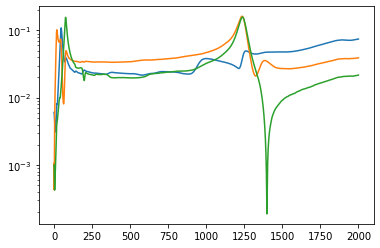

In [14]:
sel_i = 0
freq_sel = 4000
plt.semilogy(freq[:freq_sel],np.abs(Y[0,sel_i][:freq_sel]))
plt.semilogy(freq[:freq_sel],np.abs(Y[1,sel_i][:freq_sel]))
plt.semilogy(freq[:freq_sel],np.abs(Y[2,sel_i][:freq_sel]))

#plt.xlim(0,77)

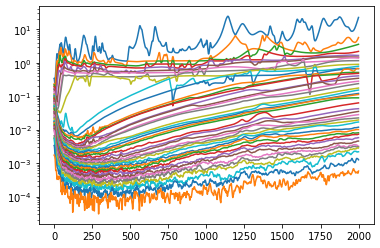

In [15]:
s_list = []
for i in range(4000):
    U, s, VT = np.linalg.svd(Y_tran[:,:,i])
    s_list.append(s)

plt.semilogy(freq,s_list);

In [16]:
freq_sel = 50
sel = 1

U, s, VT = np.linalg.svd(Y_tran[:,:,freq_sel])
Uk = U[:, sel]

In [18]:
df = pd.read_excel(AB, sheet_name='Sensors')
pos_array = df[["Position_1","Position_2","Position_3"]].to_numpy()*1000
point_cloud = pv.PolyData(pos_array)

actor_points = view3D.plot.add_mesh(point_cloud,name = "mesh",render_points_as_spheres = True, color = "k",point_size = 10,clim = [-1,1], cmap="viridis",scalars = np.zeros(15))

pts = point_cloud.points.copy()

In [17]:
n_sen = pts.shape[0]
n_ax = pts.shape[1]

empty = np.zeros_like(pts,dtype = complex)

for i in range(n_sen):
    for j in range(n_ax):
        empty[i,j] = Uk[(i)*3+j]

df = pd.read_excel(AB, sheet_name='Sensors')
new = np.zeros_like(empty,dtype = complex)

for s,angle in enumerate(df[["Orientation_1","Orientation_2","Orientation_3"]].to_numpy()):
    R = eulerAnglesToRotationMatrix(angle*np.pi/180)
    new[s,:] = empty[s,:]@R
    

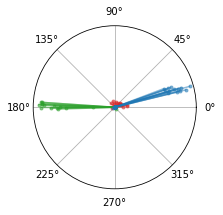

In [18]:
scale = 20

complex_plot_3D(new)
mode_dict = dict()

mode_dict["freq"] = 0#a.nat_freq[select]
mode_dict["damp"] = 0
mode_dict["mcf"] = 0

mode_dict["animation_pts"] = mode_animation(new,scale,no_points = 60)
mode_dict["mesh"] = point_cloud
mode_dict["or_pts"] = pts

mode_dict["scalars"] = True
mode_dict["fps"] = 30

view3D.add_modeshape(mode_dict,run_animation = True)